<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB46 · Cinemática: dónde está cada cosa

**Parte 6 · Simulación de bípedos a fondo — Bloque A: MuJoCo por dentro — Lección 2**

> En el NB45 vimos que el estado de un robot son sus coordenadas generalizadas, `qpos`: ángulos y poco más. Pero a nosotros nos importan otras cosas: **dónde está el pie**, **hacia dónde mira el torso**, **a qué velocidad se mueve la punta del pie**. La **cinemática** es la parte de la mecánica que traduce entre las dos cosas, sin preocuparse de fuerzas: solo geometría y movimiento.

Hoy aprenderás las tres herramientas de cinemática que usa cualquier ingeniero de robótica, todos los días:

1. **Rotaciones en 3D**: matrices de rotación, ángulos de Euler y **cuaterniones**. Por qué hay tres formas, cuál usar y las trampas de cada una (alguna, famosa en entrevistas).
2. **El jacobiano**: la matriz que convierte velocidades de las articulaciones en velocidades del pie (y fuerzas del pie en pares de los motores). Es la **J** de la ecuación del NB45.
3. **La cinemática inversa**: "quiero el pie **aquí**; ¿qué ángulos pongo?". La pregunta que hay detrás de cualquier robot que coloca un pie o una mano.

En el hilo de Python, el álgebra lineal de NumPy **a fondo** (`np.linalg`), y tres hábitos de profesional: **funciones puras**, **docstrings** en el formato estándar, y **tests** de verdad con pytest para el código numérico.

Una advertencia: este notebook tiene bastantes matemáticas. Todas se construyen sobre lo que ya sabes (vectores y matrices, NB12-NB14; pendientes, NB16; senos y cosenos, NB36), y todas se **comprueban** con números de MuJoCo. Si una sección se hace dura, léela con calma y ejecuta sus celdas: ver los números ayuda mucho.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)

## 1 · Marcos de referencia

### Cada cuerpo tiene sus propios ejes

Para decir "dónde está" algo hace falta un **origen** y unos **ejes**: eso es un **marco de referencia** (*frame*). En MuJoCo hay uno fijo, el del **mundo**: el origen en el suelo, x hacia delante, y hacia la izquierda, z hacia arriba (NB42).

Pero **cada cuerpo** tiene, además, su propio marco, pegado a él: un origen (normalmente, la articulación que lo une a su madre) y unos ejes que **giran con él**. Piensa en tu mano: "el dedo índice está 8 cm hacia delante **de la palma**" es una descripción en el marco de la mano, que vale aunque gires el brazo.

En el NB42 ya lo usamos sin decirlo: cada `pos` del MJCF es **relativa al marco de la madre**. El muslo está en `pos="0 -0.1 0"`, es decir, 10 cm a la derecha **del torso**, no del mundo.

MuJoCo guarda las dos versiones:

| | En el modelo (relativo a la madre, fijo) | En los datos (en el mundo, calculado) |
|---|---|---|
| posición | `modelo.body_pos` | `datos.xpos` |
| orientación | `modelo.body_quat` | `datos.xquat`, `datos.xmat` |

Lo que hace `mj_kinematics` (NB45) es justo **pasar del modelo a los datos**: encadenar los marcos relativos, uno detrás de otro, desde el mundo hasta cada pieza (¡la cadena del NB36, en 3D!). A eso se le llama **cinemática directa** (*forward kinematics*).

Comprobémoslo con el muslo derecho de Zancudo:


In [2]:
modelo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
datos = mujoco.MjData(modelo)
mujoco.mj_kinematics(modelo, datos)

print("muslo_d, relativo al torso: ", modelo.body("muslo_d").pos)
print("torso, en el mundo:         ", datos.body("torso").xpos)
print("muslo_d, en el mundo:       ", datos.body("muslo_d").xpos)

muslo_d, relativo al torso:  [ 0.  -0.1  0. ]
torso, en el mundo:          [0.    0.    0.865]
muslo_d, en el mundo:        [ 0.    -0.1    0.865]


El torso está en (0, 0, 0,865) y el muslo, 0,1 m a su derecha (y = −0,1): (0, −0,1, 0,865). Con el robot sin girar, "en el mundo" es simplemente "la posición de la madre + la relativa". Pero en cuanto algo gira, hay que **girar** la posición relativa antes de sumarla. Para eso necesitamos saber describir giros en 3D.


## 2 · Rotaciones en 3D: la matriz de rotación

### De 2D a 3D

En el NB36 giramos vectores en 2D con la matriz

```
   R(θ) = | cos θ   −sen θ |
          | sen θ    cos θ |
```

En 3D, un giro alrededor de **un eje** de coordenadas es lo mismo, dejando quieta la coordenada de ese eje. Por ejemplo, alrededor de **z** (como girar sobre ti mismo, mirando al suelo desde arriba): x e y giran como en 2D, y z no cambia. Escribamos los tres giros básicos como **funciones** de Python:


In [3]:
def giro_x(angulo: float) -> np.ndarray:
    c, s = np.cos(angulo), np.sin(angulo)
    return np.array([[1, 0, 0],
                     [0, c, -s],
                     [0, s, c]])

def giro_y(angulo: float) -> np.ndarray:
    c, s = np.cos(angulo), np.sin(angulo)
    return np.array([[c, 0, s],
                     [0, 1, 0],
                     [-s, 0, c]])

def giro_z(angulo: float) -> np.ndarray:
    c, s = np.cos(angulo), np.sin(angulo)
    return np.array([[c, -s, 0],
                     [s, c, 0],
                     [0, 0, 1]])

print(giro_z(np.pi / 2) @ np.array([1, 0, 0]))     # el eje x, girado 90° alrededor de z

[0. 1. 0.]


El vector (1, 0, 0), que apunta hacia delante, girado 90° alrededor de z (hacia la izquierda, en sentido antihorario visto desde arriba) apunta ahora a (0, 1, 0): hacia la **izquierda**. Correcto.

(Fíjate en `giro_y`: el `−s` está abajo a la izquierda, no arriba a la derecha como en las otras dos. No es un error: es lo que sale para que el giro sea "antihorario mirando desde la punta del eje y" con los ejes ordenados x, y, z. Es una de esas cosas que conviene **comprobar** con números en vez de memorizar.)

### Qué significa cada número: las columnas son los ejes

Una forma muy útil de entender una matriz de rotación: **sus columnas son los ejes del cuerpo, vistos desde el mundo**. La primera columna dice hacia dónde apunta el eje x del cuerpo; la segunda, el y; la tercera, el z.


In [4]:
R = giro_z(np.pi / 2)
print("eje x del cuerpo (1.ª columna):", R[:, 0])
print("eje y del cuerpo (2.ª columna):", R[:, 1])
print("eje z del cuerpo (3.ª columna):", R[:, 2])

eje x del cuerpo (1.ª columna): [0. 1. 0.]
eje y del cuerpo (2.ª columna): [-1.  0.  0.]
eje z del cuerpo (3.ª columna): [0. 0. 1.]


Tras girar 90° a la izquierda: el "delante" del cuerpo apunta a la izquierda del mundo (0, 1, 0), su "izquierda" apunta hacia atrás (−1, 0, 0) y su "arriba" sigue arriba. Esto es exactamente lo que hacíamos con la IMU en el NB41: leer la **tercera columna** de `xmat` (la "arriba" del torso) para saber cuánto estaba inclinado.

`R[:, 0]` usa la indexación de NumPy del NB27: `:` en las filas significa "todas", y `0` en las columnas, "la primera". O sea: la primera **columna**.


### Tres propiedades que hay que saber

Una matriz de rotación no es una matriz cualquiera. Cumple siempre tres cosas, y conviene saberlas para la entrevista y para **detectar errores**:

1. **Sus columnas tienen longitud 1 y son perpendiculares entre sí** (los ejes del cuerpo son ejes de verdad: ni se estiran ni se tuercen). En fórmula: **RᵀR = I** (la traspuesta por ella misma da la identidad). A las matrices así se las llama **ortogonales**.
2. **Su determinante vale +1** (no −1: eso sería un **espejo**, que cambia la izquierda por la derecha; ningún giro hace eso).
3. **Su inversa es su traspuesta**: deshacer un giro es tan fácil como trasponer la matriz. Rᵀ "desgira".


In [5]:
R = giro_x(0.3) @ giro_y(-1.1) @ giro_z(2.0)        # un giro cualquiera, combinando tres

print("RᵀR =\n", R.T @ R)
print("determinante:", np.linalg.det(R))
print("¿la inversa es la traspuesta?", np.allclose(np.linalg.inv(R), R.T))

RᵀR =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
determinante: 1.0000000000000002
¿la inversa es la traspuesta? True


Las tres se cumplen (salvo el ruido de los decimales, del orden de 10⁻¹⁶, NB06).

La tercera es muy práctica. Calcular la **inversa** de una matriz cualquiera es caro y delicado (sección 6); trasponer es gratis. Cada vez que tengas que "deshacer" un giro, traspón.

### Componer giros: el orden importa

Girar con R₁ y **después** con R₂ es multiplicar las matrices: **R₂ · R₁** (la que actúa primero va a la **derecha**, junto al vector). Y aquí está la primera gran diferencia con los giros en 2D: **en 3D, el orden importa**.


In [6]:
A = giro_x(np.pi / 2) @ giro_z(np.pi / 2)     # primero z, después x
B = giro_z(np.pi / 2) @ giro_x(np.pi / 2)     # primero x, después z
print("¿mismo giro?", np.allclose(A, B))
print(A)
print(B)

¿mismo giro? False
[[ 0. -1.  0.]
 [ 0.  0. -1.]
 [ 1.  0.  0.]]
[[ 0. -0.  1.]
 [ 1.  0. -0.]
 [ 0.  1.  0.]]


**No** es el mismo giro. Compruébalo con un libro o con el móvil: gíralo 90° alrededor del eje vertical y luego 90° alrededor del eje que apunta hacia ti; después vuelve a empezar, haciéndolo al revés. Acaba en posturas distintas.

En matemáticas se dice que las rotaciones 3D **no conmutan** (A·B ≠ B·A), igual que las matrices en general (NB14). En 2D sí conmutaban: girar 30° y luego 40° es lo mismo que 40° y luego 30°. Esta diferencia es la raíz de casi todas las complicaciones de los giros 3D... empezando por la siguiente sección.

### Cambiar un punto de marco

Con lo anterior ya podemos hacer la operación más común de la cinemática: pasar un punto del marco de un cuerpo al del mundo, y al revés. Si un cuerpo está en la posición **p** con orientación **R**, un punto que en el marco del cuerpo tiene coordenadas **a** está, en el mundo, en:

```
   en el mundo  =  p  +  R · a
```

(primero se **gira** el punto con el cuerpo, luego se **traslada** a donde está el cuerpo). Y al revés, deshaciendo: **a = Rᵀ · (en el mundo − p)**.

Por ejemplo: ¿dónde está, **para el torso**, el pie derecho? Es la pregunta que se haría el "cerebro" de un robot que solo conoce su propio cuerpo:


In [7]:
datos.qpos[2] = 0.3                              # inclinamos el torso 0,3 rad
datos.qpos[3] = 0.5                              # y adelantamos la pierna derecha
mujoco.mj_kinematics(modelo, datos)

p = datos.body("torso").xpos
R = datos.body("torso").xmat.reshape(3, 3)       # MuJoCo guarda la matriz "aplanada", en 9 números
pie_en_el_mundo = datos.body("pie_d").xpos
pie_para_el_torso = R.T @ (pie_en_el_mundo - p)

print("pie derecho en el mundo:     ", pie_en_el_mundo)
print("pie derecho para el torso:   ", pie_para_el_torso)
print("y de vuelta al mundo:        ", p + R @ pie_para_el_torso)

pie derecho en el mundo:      [ 0.1589 -0.1     0.0809]
pie derecho para el torso:    [ 0.3835 -0.1    -0.7021]
y de vuelta al mundo:         [ 0.1589 -0.1     0.0809]


Dos detalles:

- **`xmat` viene aplanada**: MuJoCo guarda la matriz 3 × 3 como 9 números seguidos, fila tras fila (es lo natural en C). `.reshape(3, 3)` la vuelve a poner en forma de matriz (NB27: `reshape` no copia, da una **vista**; cuidado con guardarla, NB45).
- **Ida y vuelta**: pasar al marco del torso y volver da el mismo punto. Siempre que escribas una transformación de marcos, haz esta comprobación: es la forma más rápida de pillar un error de signo o de orden.

Para el torso, el pie está a 0,8 m "por debajo" de él (en su z) y algo adelantado (en su x), aunque en el mundo el torso esté inclinado. Esta forma de mirar las cosas "desde el cuerpo" es la que usaremos para las **observaciones** de los robots 3D en el NB54: a una política le interesa dónde están los pies **respecto a ella**, no respecto al origen del mundo.


## 3 · Ángulos de Euler y el bloqueo de cardán

### Tres ángulos

Una matriz de rotación tiene 9 números, pero (por las propiedades de la sección 2) solo 3 son independientes. Lo más intuitivo para un humano es describir un giro con **3 ángulos**, uno detrás de otro: por ejemplo, los del avión (NB41), **guiñada** (*yaw*, girar a izquierda o derecha, alrededor de z), **cabeceo** (*pitch*, morro arriba o abajo, alrededor de y) y **alabeo** (*roll*, inclinar las alas, alrededor de x):

```
   R  =  giro_z(guiñada) · giro_y(cabeceo) · giro_x(alabeo)
```

A eso se le llama **ángulos de Euler** (por el matemático suizo Leonhard Euler). Es cómodo para **leer** una orientación ("el robot está inclinado 10° hacia delante y girado 30° a la izquierda"), y por eso los usaremos para **mostrar** orientaciones. Pero tiene dos problemas serios.

**Problema 1: hay docenas de convenios.** ¿Qué eje primero? ¿Los ejes del mundo o los del cuerpo que va girando? z-y-x, x-y-z, z-x-z... Hay **12** órdenes posibles, y cada uno en versión "ejes fijos" (*extrínseco*) o "ejes que giran" (*intrínseco*). Dos bibliotecas que dicen "ángulos de Euler" pueden estar hablando de cosas distintas, y mezclarlas da errores silenciosos. (MuJoCo tiene `mju_euler2Quat`, a la que hay que decirle el orden con un texto como `"xyz"`; minúsculas para ejes que giran, mayúsculas para ejes fijos.)

**Problema 2: el bloqueo de cardán.** Lo anunciamos en el NB45; ahora lo vamos a **ver**.


### El bloqueo de cardán, con números

Con el convenio de arriba, pon el cabeceo justo a **90°** (el morro del avión apuntando al cielo). Ahora prueba a cambiar la guiñada **o** el alabeo: algo pasa.


In [8]:
def euler(guinada: float, cabeceo: float, alabeo: float) -> np.ndarray:
    return giro_z(guinada) @ giro_y(cabeceo) @ giro_x(alabeo)

noventa = np.pi / 2
R1 = euler(guinada=0.5, cabeceo=noventa, alabeo=0.0)
R2 = euler(guinada=0.0, cabeceo=noventa, alabeo=-0.5)
print("guiñada 0,5 y alabeo 0   →  mismo giro que guiñada 0 y alabeo −0,5?", np.allclose(R1, R2))

guiñada 0,5 y alabeo 0   →  mismo giro que guiñada 0 y alabeo −0,5? True


**Sí**: con el cabeceo a 90°, aumentar la guiñada 0,5 rad es **exactamente** lo mismo que disminuir el alabeo 0,5 rad. Los dos ángulos se han "fundido" en uno: ya no son dos formas independientes de girar, sino **una**. Hemos perdido un grado de libertad: con los tres ángulos, en esa postura, solo podemos describir giros de **dos** formas. Eso es el **bloqueo de cardán** (*gimbal lock*).

¿Y qué problema hay? Que cerca de esa postura, para hacer un giro pequeño en la dirección "perdida", los ángulos tienen que dar **saltos enormes**. Un controlador que use ángulos de Euler, o una red neuronal que los reciba como observación, se vuelve loco. En el Apolo 11, la plataforma de navegación avisaba con una luz al acercarse al bloqueo, y los astronautas tenían que evitar esas orientaciones.

El nombre viene del **cardán** (*gimbal*): el soporte de anillos que permite a una brújula o a un giróscopo mantenerse horizontal. Con tres anillos, en cierta postura dos de ellos se alinean y el conjunto "pierde" un eje.

**Para la entrevista:** "Los ángulos de Euler son intuitivos y sirven para mostrar orientaciones, pero tienen singularidades (bloqueo de cardán) y ambigüedad de convenios. Para calcular y para guardar orientaciones se usan matrices de rotación o, sobre todo, cuaterniones".


## 4 · Cuaterniones

### Qué es un cuaternión

Un resultado precioso de Euler (otra vez él): **cualquier** giro en 3D, por complicado que sea, es equivalente a girar un cierto ángulo **θ** alrededor de un cierto **eje** (un vector unitario **e**). Siempre. A esto se le llama la representación **eje-ángulo**.

Un **cuaternión** es una forma de guardar ese eje y ese ángulo en **4 números**:

```
   q  =  ( cos(θ/2),   sen(θ/2)·eₓ,   sen(θ/2)·e_y,   sen(θ/2)·e_z )
            w              x               y               z
```

El primero (**w**) es la parte "escalar" y los otros tres (x, y, z), la parte "vectorial". Así, por ejemplo:

- **Sin girar** (θ = 0): cos 0 = 1, sen 0 = 0 → **(1, 0, 0, 0)**. Es el cuaternión que vimos en el NB45 en `qpos`.
- **90° alrededor de z**: cos 45° = sen 45° = 0,7071 → **(0,7071, 0, 0, 0,7071)**.

¿Por qué θ/2 y no θ? Es lo que hace que la multiplicación de cuaterniones (en un momento) componga giros correctamente; la explicación completa necesita el álgebra de los cuaterniones, que inventó el irlandés William Rowan Hamilton en 1843 (cuenta la leyenda que grabó la fórmula a navaja en un puente de Dublín, de la emoción). Para usarlos no hace falta: MuJoCo tiene funciones para todo. Comprobemos el de 90° alrededor de z:


In [9]:
q = np.zeros(4)
mujoco.mju_axisAngle2Quat(q, np.array([0.0, 0.0, 1.0]), np.pi / 2)   # (cuaternión de salida, eje, ángulo)
print("cuaternión:", q)
print("su longitud:", np.linalg.norm(q))

cuaternión: [0.7071 0.     0.     0.7071]
su longitud: 1.0


(0,7071, 0, 0, 0,7071), como habíamos calculado. Y su **longitud** es 1: los cuaterniones que representan giros son siempre **unitarios** (porque cos² + sen² = 1). Esa es la "atadura" de la que hablábamos en el NB45: 4 números, pero solo 3 libres.

Fíjate otra vez en el estilo de C: `mju_axisAngle2Quat` no devuelve el cuaternión, sino que **rellena** el array `q` que le pasamos. Las funciones de MuJoCo que empiezan por **`mju_`** (*u* de *utility*) son utilidades matemáticas; las que empiezan por **`mj_`** hacen cosas con el modelo y los datos.

Convertir a matriz de rotación, y girar un vector:


In [10]:
R = np.zeros(9)
mujoco.mju_quat2Mat(R, q)                    # cuaternión → matriz (aplanada)
print(R.reshape(3, 3))

girado = np.zeros(3)
mujoco.mju_rotVecQuat(girado, np.array([1.0, 0.0, 0.0]), q)
print("el eje x, girado:", girado)

[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
el eje x, girado: [0. 1. 0.]


La misma matriz que `giro_z(π/2)` de la sección 2, y el eje x girado apunta a (0, 1, 0). Todo cuadra.

### Trampa de entrevista: ¿w primero o w último?

MuJoCo escribe los cuaterniones como **(w, x, y, z)**: la parte escalar **primero**. Pero **no todo el mundo** lo hace así. SciPy (`scipy.spatial.transform.Rotation`), ROS (el sistema operativo de robots más usado), Unity, PyBullet e Isaac Gym los escriben **(x, y, z, w)**: la escalar **al final**. Eigen (C++) depende de la función...

Si pasas un cuaternión de una biblioteca a otra sin reordenar, obtienes **otro giro**, y ningún error. Es uno de los fallos más comunes (y más difíciles de encontrar) al conectar un simulador con un robot real o con otra herramienta. Mira lo que pasa si confundimos el orden de nuestro cuaternión de 90° alrededor de z:


In [11]:
mal = np.array([q[1], q[2], q[3], q[0]])     # el mismo, escrito (x, y, z, w) y leído como (w, x, y, z)
R_mal = np.zeros(9)
mujoco.mju_quat2Mat(R_mal, mal)
print(R_mal.reshape(3, 3))

[[-1.  0.  0.]
 [ 0. -0.  1.]
 [ 0.  1.  0.]]


Una matriz de rotación perfectamente válida... de **otro** giro: 180° alrededor de un eje inclinado. Nada avisa del error.

**Regla:** cada vez que un cuaternión cruza una frontera (de una biblioteca a otra, de un fichero, de un mensaje de red), **comprueba el convenio**. Y si puedes, comprueba con un giro conocido (como el de 90° alrededor de z) que la conversión da lo que esperas.

### Doble cobertura: q y −q son el mismo giro

Una propiedad curiosa, y otra pregunta típica: el cuaternión **q** y su opuesto **−q** (todos los números cambiados de signo) representan **el mismo giro**:


In [12]:
R_menos = np.zeros(9)
mujoco.mju_quat2Mat(R_menos, -q)
print("¿mismo giro?", np.allclose(R, R_menos))

¿mismo giro? True


Tiene sentido: −q corresponde a girar θ + 360° alrededor del mismo eje (el cos y el sen de la mitad cambian de signo), y dar una vuelta completa de más no cambia nada. Se dice que los cuaterniones son una **doble cobertura** de las rotaciones: cada giro tiene **dos** cuaterniones.

¿Por qué importa? Por dos razones prácticas:

1. **Comparar cuaterniones con `==` o con `np.allclose` está mal**: q y −q son el mismo giro y la comparación dice que no. Hay que comparar los **giros** (las matrices), o comprobar si q ≈ q' **o** q ≈ −q'.
2. **Si una red neuronal recibe un cuaternión como observación**, puede ver "saltos" bruscos de q a −q aunque el robot apenas se haya movido. Por eso, en las observaciones de robots se suele dar otra cosa: la **gravedad vista desde el cuerpo** (la tercera fila de la matriz), que veremos en el NB54. O se fuerza a que w sea siempre positivo.

### Componer giros con cuaterniones

Componer dos giros es **multiplicar** sus cuaterniones (con la multiplicación de Hamilton, que no es la de NumPy casilla a casilla). MuJoCo la tiene en `mju_mulQuat`. Comprobemos que da lo mismo que multiplicar las matrices:


In [13]:
def cuaternion(eje, angulo: float) -> np.ndarray:
    q = np.zeros(4)
    mujoco.mju_axisAngle2Quat(q, np.asarray(eje, dtype=float), angulo)
    return q

def matriz(q: np.ndarray) -> np.ndarray:
    R = np.zeros(9)
    mujoco.mju_quat2Mat(R, q)
    return R.reshape(3, 3)

qz = cuaternion([0, 0, 1], np.pi / 2)
qx = cuaternion([1, 0, 0], np.pi / 2)
compuesto = np.zeros(4)
mujoco.mju_mulQuat(compuesto, qx, qz)          # primero z, después x  (como A en la sección 2)
print("¿igual que con matrices?", np.allclose(matriz(compuesto), giro_x(np.pi / 2) @ giro_z(np.pi / 2)))

¿igual que con matrices? True


Igual. Y fíjate en las dos funciones que acabamos de escribir, `cuaternion` y `matriz`: **envuelven** el estilo de C de MuJoCo ("pásame un array y lo relleno") en funciones al estilo de Python ("te devuelvo el resultado"). Es un patrón muy habitual: escribir una capa fina de funciones cómodas encima de una biblioteca de bajo nivel. `np.asarray(eje, dtype=float)` convierte lo que nos pasen (una lista, una tupla, un array de enteros...) en un array de decimales, que es lo que pide MuJoCo, **sin copiar** si ya lo era.

### ¿Por qué todo el mundo usa cuaterniones?

| | Matriz de rotación | Ángulos de Euler | Cuaternión |
|---|---|---|---|
| Números | 9 | 3 | 4 |
| Bloqueo de cardán | no | **sí** | no |
| Componer giros | multiplicar (27 multiplicaciones) | complicado | multiplicar (16) |
| Girar un vector | directo (9 multiplicaciones) | hay que convertir | algo más caro |
| Se "estropea" con los errores de redondeo | sí: deja de ser ortogonal, hay que reparar | — | poco: basta con normalizar (dividir por la longitud) |
| Interpolar entre dos giros | difícil | da movimientos raros | **fácil y bonito** (slerp) |
| Legible por humanos | regular | **muy** | poco |

Por eso MuJoCo **guarda** las orientaciones como cuaterniones (`qpos` de las articulaciones libres, `xquat`), te da también la matriz (`xmat`) porque es cómoda para girar vectores, y deja los ángulos de Euler para **mostrar** al humano.

### Interpolar giros: slerp

La última ventaja de la tabla merece un ejemplo, porque la usaremos al imitar movimientos (NB57). Imagina que quieres que el torso pase **suavemente** de una orientación a otra. Con cuaterniones hay una fórmula para ir de q₀ a q₁ por el camino **más corto** y a **velocidad de giro constante**: la **interpolación esférica lineal**, *slerp*. La escribimos nosotros:


In [14]:
def slerp(q0: np.ndarray, q1: np.ndarray, t: float) -> np.ndarray:
    coseno = np.dot(q0, q1)
    if coseno < 0:                     # doble cobertura: elegimos el camino corto
        q1, coseno = -q1, -coseno
    if coseno > 0.9995:                # casi iguales: basta con una línea recta (y evitamos dividir por casi 0)
        q = q0 + t * (q1 - q0)
        return q / np.linalg.norm(q)
    angulo = np.arccos(coseno)
    return (np.sin((1 - t) * angulo) * q0 + np.sin(t * angulo) * q1) / np.sin(angulo)

inicio = cuaternion([0, 0, 1], 0.0)
final = cuaternion([0, 0, 1], 2.0)
for t in [0, 0.25, 0.5, 0.75, 1]:
    q_t = slerp(inicio, final, t)
    angulo_t = 2 * np.arccos(np.clip(q_t[0], -1, 1))
    print(f"t = {t:.2f}  →  ángulo {angulo_t:.2f} rad")

t = 0.00  →  ángulo 0.00 rad
t = 0.25  →  ángulo 0.50 rad
t = 0.50  →  ángulo 1.00 rad
t = 0.75  →  ángulo 1.50 rad
t = 1.00  →  ángulo 2.00 rad


El ángulo avanza **uniformemente**: 0, 0,5, 1, 1,5, 2 rad. Tres detalles de la función que son "de profesional":

- El `if coseno < 0` usa la **doble cobertura**: si q₀ y q₁ están "en lados opuestos", se cambia q₁ por −q₁ (el mismo giro), para no dar la vuelta larga.
- El `if coseno > 0.9995` evita dividir por `sen(ángulo)` cuando el ángulo es casi 0 (dividir por un número casi cero amplifica los errores de redondeo, NB06). Es un **caso límite**: el código numérico profesional siempre los tiene en cuenta.
- Para sacar el ángulo de q_t usamos `2 · arccos(w)` (deshaciendo el cos(θ/2)), y `np.clip(..., -1, 1)` por si el redondeo deja w en 1,0000000002, que haría fallar a `arccos`.


## 5 · Cinemática directa de la pierna de Zancudo

### Un punto de referencia: el site

Pasemos a Zancudo. Queremos estudiar dónde está su **tobillo** derecho. Podríamos usar la posición del cuerpo `pie_d` (cuyo origen está en el tobillo), pero lo profesional es marcar el punto que nos interesa con un **site** (NB42): un punto con nombre, sin masa ni forma, pegado a un cuerpo. Zancudo no tiene ninguno en el tobillo, así que se lo añadimos al MJCF. Por ahora, de la forma más sencilla: leyendo el fichero como texto y **reemplazando** un trozo (en el NB50 veremos la forma profesional de modificar modelos desde Python, `MjSpec`):


In [15]:
from pathlib import Path

texto = Path("robots/zancudo.xml").read_text(encoding="utf-8")
buscado = '<body name="pie_d" pos="0 0 -0.4">'
assert texto.count(buscado) == 1, "el trozo a reemplazar debe aparecer exactamente una vez"
texto = texto.replace(buscado, buscado + '\n            <site name="tobillo_d" pos="0 0 0"/>')

modelo = mujoco.MjModel.from_xml_string(texto)
datos = mujoco.MjData(modelo)
TOBILLO = modelo.site("tobillo_d").id
print("sites del modelo:", [modelo.site(i).name for i in range(modelo.nsite)])

sites del modelo:

 ['imu', 'tobillo_d']


Fíjate en el `assert` antes del `replace`: si algún día alguien cambia el MJCF y ese trozo ya no aparece (o aparece dos veces), `replace` no daría ningún error: simplemente no haría nada (o lo haría dos veces), y el site no estaría donde creemos. El `assert` convierte ese fallo silencioso en un error **inmediato y con mensaje**. Es lo que se llama **programación defensiva**: comprobar las suposiciones en el código, no solo en la cabeza.

### La fórmula, a mano

Con el torso sin girar y en su sitio (raíz a cero), el tobillo derecho depende solo de la cadera (c) y la rodilla (r). Es la cadena de dos eslabones del NB36: muslo de 0,4 m y pierna de 0,4 m, colgando de la cadera, que está a 0,865 m de altura. Con el convenio de Zancudo (ángulo positivo de cadera = pierna hacia delante; la rodilla se dobla con ángulos negativos):

```
   x = 0,4 · sen(c)  +  0,4 · sen(c + r)
   z = 0,865  −  0,4 · cos(c)  −  0,4 · cos(c + r)
```

(el ángulo de la pierna respecto a la vertical es c + r: el de la cadera más lo que se dobla la rodilla.) La programamos y la comparamos con MuJoCo:


In [16]:
def tobillo_a_mano(cadera: float, rodilla: float) -> tuple[float, float]:
    x = 0.4 * np.sin(cadera) + 0.4 * np.sin(cadera + rodilla)
    z = 0.865 - 0.4 * np.cos(cadera) - 0.4 * np.cos(cadera + rodilla)
    return x, z

datos.qpos[:] = 0
datos.qpos[3], datos.qpos[4] = 0.5, -0.3            # cadera y rodilla derechas
mujoco.mj_kinematics(modelo, datos)
print("a mano:   x = %.6f   z = %.6f" % tobillo_a_mano(0.5, -0.3))
print("MuJoCo:   x = %.6f   z = %.6f" % (datos.site_xpos[TOBILLO][0], datos.site_xpos[TOBILLO][2]))

a mano:   x = 0.271238   z = 0.121940
MuJoCo:   x = 0.271238   z = 0.121940


Coinciden en todos los decimales. Esto es la **cinemática directa**: ángulos → posición. Para una pierna plana de dos eslabones, la fórmula es corta. Para un humanoide de 30 articulaciones en 3D, sería larguísima, y por eso se deja a MuJoCo: encadena los marcos de la sección 1 con las rotaciones de la sección 2.

(Un detalle de Python: `"... %.6f ... %.6f" % (a, b)` es el formato **antiguo** de Python, con `%`, que todavía verás en mucho código. Equivale a `f"... {a:.6f} ... {b:.6f}"`. Y fíjate en que `tobillo_a_mano` devuelve una **tupla** de dos números, que encaja directamente en los dos `%.6f`.)


## 6 · El jacobiano

### La pendiente, con muchas entradas y muchas salidas

En el NB16 vimos la **pendiente** de una función: cuánto cambia la salida cuando la entrada cambia un poquito. La posición del tobillo es una función con **muchas entradas** (los 9 números de `qpos`) y **varias salidas** (x, y, z). Así que no hay **una** pendiente, sino **muchas**: cuánto cambia **cada** salida al mover **cada** entrada. Puestas en una tabla, con una fila por salida y una columna por entrada, forman el **jacobiano** (por el matemático alemán Carl Jacobi):

```
             cadera_d     rodilla_d    ...
   x   |   ∂x/∂cadera   ∂x/∂rodilla   ...  |
   y   |   ∂y/∂cadera   ∂y/∂rodilla   ...  |
   z   |   ∂z/∂cadera   ∂z/∂rodilla   ...  |
```

Para el tobillo de Zancudo, es una matriz de 3 filas (x, y, z) y 9 columnas (`nv`).

### Calcularlo "a lo bruto": diferencias finitas

La forma más directa de calcular una pendiente es la del NB16: mover un poquito la entrada y ver cuánto cambia la salida. Con **diferencias centradas** (moviendo un poquito hacia los dos lados, que es más preciso):

```
   ∂x/∂q  ≈  ( x(q + ε) − x(q − ε) ) / (2ε)
```

Escribamos una función que lo haga para todas las columnas. Y escribámosla **bien**: que no toque los `datos` de fuera, sino que use los suyos propios. Enseguida veremos por qué importa.


In [17]:
def jacobiano_numerico(modelo: mujoco.MjModel, qpos: np.ndarray, site: int, eps: float = 1e-6) -> np.ndarray:
    propios = mujoco.MjData(modelo)          # sus propios datos: no toca los de nadie
    J = np.zeros((3, modelo.nv))
    for k in range(modelo.nv):
        for signo in (+1, -1):
            propios.qpos[:] = qpos
            propios.qpos[k] += signo * eps
            mujoco.mj_kinematics(modelo, propios)
            J[:, k] += signo * propios.site_xpos[site] / (2 * eps)
    return J

q_ejemplo = np.zeros(modelo.nq)
q_ejemplo[3], q_ejemplo[4] = 0.4, -0.8
J_num = jacobiano_numerico(modelo, q_ejemplo, TOBILLO)
print(J_num)

[[ 1.      0.     -0.7368  0.7368  0.3684  0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      1.      0.      0.     -0.1558  0.      0.      0.      0.    ]]


(Un aviso: este truco de `qpos[k] += eps` funciona en Zancudo porque `nq = nv` y todas sus articulaciones son bisagras o deslizaderas. Con cuaterniones en `qpos` (NB45), sumar `eps` a una casilla rompería la longitud 1 del cuaternión: habría que usar `mj_integratePos`. Otra razón para preferir el jacobiano de MuJoCo.)

Leamos las columnas:

- **Columna 0 (raíz x)**: (1, 0, 0). Si todo el robot avanza 1 m, el tobillo avanza 1 m. Claro.
- **Columna 1 (raíz z)**: (0, 0, 1). Igual, hacia arriba.
- **Columna 2 (giro del torso)**: si el torso gira, el tobillo, que está 0,74 m por debajo, se mueve hacia **atrás**: −0,74 m por radián.
- **Columna 3 (cadera derecha)**: hacia delante 0,74 m por radián.
- **Columna 4 (rodilla derecha)**: hacia delante 0,37 y hacia abajo 0,16.
- **Columnas 6, 7, 8 (pierna izquierda)**: ¡ceros! Mover la pierna izquierda no mueve el tobillo derecho.
- **Columna 5 (tobillo)**: cero también: el site está **en** el eje del tobillo, así que girar el tobillo no lo desplaza.
- **Fila 1 (y)**: toda a cero. Zancudo es plano: nada lo mueve de lado.


### El jacobiano de MuJoCo, y una trampa

Calcular el jacobiano con diferencias finitas cuesta 2 × `nv` cinemáticas completas, y tiene error numérico (por el `eps`). MuJoCo lo calcula **exacto** y mucho más rápido, con `mj_jacSite` (y sus hermanas: `mj_jacBody` para el origen de un cuerpo, `mj_jacBodyCom` para su centro de masas, `mj_jacSubtreeCom` para el CdM de todo lo que cuelga de un cuerpo, `mj_jac` para cualquier punto...). Recibe **dos** arrays para rellenar: el jacobiano de la **posición** (`jacp`) y el de la **rotación** (`jacr`, sección siguiente). Si uno no te interesa, pasas `None`:


In [18]:
datos.qpos[:] = q_ejemplo
mujoco.mj_kinematics(modelo, datos)

J = np.zeros((3, modelo.nv))
mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)
print(J)

[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


¡Todo **ceros**! Y ningún error. Es una trampa clásica: los jacobianos de MuJoCo necesitan, además de la cinemática, unas cantidades que calcula **otra** etapa, `mj_comPos` (las posiciones de los centros de masas y los ejes de las articulaciones "vistos desde" el CdM). `mj_kinematics` no las calcula. La solución segura es llamar a **`mj_forward`** (que lo hace todo, NB45), o, si quieres ahorrar, `mj_kinematics` + `mj_comPos`:


In [19]:
mujoco.mj_forward(modelo, datos)
mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)
print(J)
print("diferencia máxima con el numérico:", np.abs(J - J_num).max())

[[ 1.      0.     -0.7368  0.7368  0.3684  0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      1.      0.     -0.     -0.1558  0.      0.      0.      0.    ]]
diferencia máxima con el numérico: 8.731151912577673e-11


Ahora sí, y coincide con el de diferencias finitas hasta el orden de 10⁻¹⁰ (lo que se puede esperar con `eps = 1e-6`).

**Lección general**: muchas funciones de MuJoCo dependen de que antes se haya calculado algo. Si una función te devuelve ceros o cosas raras **sin dar error**, lo primero es preguntarse: "¿he llamado a `mj_forward`?".


### Para qué sirve (1): velocidades

La primera utilidad del jacobiano: **la velocidad del tobillo es J por la velocidad de las articulaciones**:

```
   velocidad del tobillo  =  J · q̇
```

Es la regla de la cadena del NB18, aplicada a todas las articulaciones a la vez: cada articulación contribuye con "su pendiente × su velocidad", y se suman. Comprobémoslo con MuJoCo, que también sabe calcular la velocidad de un objeto directamente (`mj_objectVelocity`):


In [20]:
datos.qpos[:] = q_ejemplo
datos.qvel[:] = 0
datos.qvel[3], datos.qvel[4] = 1.0, -0.5           # cadera a 1 rad/s, rodilla a −0,5 rad/s
mujoco.mj_forward(modelo, datos)
mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)

velocidad_J = J @ datos.qvel
seis = np.zeros(6)                                  # MuJoCo devuelve 6 números: 3 de giro y 3 lineales
mujoco.mj_objectVelocity(modelo, datos, mujoco.mjtObj.mjOBJ_SITE, TOBILLO, seis, 0)   # 0 = en el marco del mundo
print("J · q̇:              ", velocidad_J)
print("mj_objectVelocity:  ", seis[3:])

J · q̇:               [0.5526 0.     0.0779]
mj_objectVelocity:   [0.5526 0.     0.0779]


Idénticas. Fíjate en que `mj_objectVelocity` devuelve **6** números: primero la velocidad de **giro** (3) y después la **lineal** (3). Es el convenio de MuJoCo para las velocidades "espaciales" (giro primero), y es fácil equivocarse: por eso cogemos `seis[3:]`. El último argumento, `0`, pide la velocidad en los ejes del mundo; con `1`, la daría en los ejes del propio objeto (sección 2).

### Para qué sirve (2): de fuerzas a pares, Jᵀf

La segunda utilidad es la **J** de la ecuación del movimiento del NB45 (Jᵀf). Si el pie empuja el suelo con una fuerza **f**, ¿qué par tiene que hacer cada motor para sostenerla? La respuesta es la **traspuesta** del jacobiano:

```
   pares de los motores  =  Jᵀ · f
```

¿Por qué la traspuesta? Por el **trabajo**: una fuerza f que mueve su punto a velocidad v hace un trabajo por segundo (potencia) de f · v; un par τ que gira su articulación a velocidad q̇, de τ · q̇. Como el trabajo hecho por los motores tiene que ser el que llega al pie, f · (J q̇) = τ · q̇ para cualquier q̇, y eso solo es posible si τ = Jᵀ f. (Es el **principio del trabajo virtual**, uno de los más bonitos de la mecánica.)

Un ejemplo con consecuencias: Zancudo sostiene su peso sobre una pierna. El suelo empuja el tobillo hacia arriba con unos 230 N. ¿Cuánto par necesita la **rodilla**, según lo doblada que esté?


In [21]:
fuerza = np.array([0.0, 0.0, 230.0])         # el suelo empuja hacia arriba con el peso de Zancudo
for rodilla in [-1.2, -0.8, -0.4, -0.1]:
    datos.qpos[:] = 0
    datos.qpos[3], datos.qpos[4] = -rodilla / 2, rodilla     # cadera a la mitad, para que el tobillo quede bajo la cadera
    mujoco.mj_forward(modelo, datos)
    mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)
    pares = J.T @ fuerza
    print(f"rodilla {rodilla:+.1f} rad  →  par en la rodilla {pares[4]:+7.1f} N·m,  en la cadera {pares[3]:+7.1f} N·m")

rodilla -1.2 rad  →  par en la rodilla   -51.9 N·m,  en la cadera    +0.0 N·m
rodilla -0.8 rad  →  par en la rodilla   -35.8 N·m,  en la cadera    -0.0 N·m
rodilla -0.4 rad  →  par en la rodilla   -18.3 N·m,  en la cadera    +0.0 N·m
rodilla -0.1 rad  →  par en la rodilla    -4.6 N·m,  en la cadera    +0.0 N·m


Con la rodilla bien doblada (−1,2 rad), la rodilla tiene que hacer **52 N·m** para sostener el peso. Casi estirada (−0,1 rad), solo **4,6 N·m**: ¡11 veces menos! La cadera, nada: con el tobillo justo debajo de ella, la fuerza vertical pasa por su eje y no hace palanca.

Esto explica algo que haces sin pensar: cuando estás de pie mucho rato, **bloqueas las rodillas** (casi estiradas), y cuando haces una sentadilla, los muslos te arden. Con la pierna estirada, el **hueso** soporta el peso; con la pierna doblada, lo soportan los **músculos** (los motores). En un robot, andar con las rodillas muy dobladas gasta mucha más energía y calienta los motores (NB40). Pero estirar del todo tiene su propio problema, que veremos en la sección 7.

(El signo menos del par de la rodilla es el convenio de Zancudo: la rodilla se dobla con ángulos negativos, así que para **impedir** que se doble más tiene que empujar en el otro sentido. En el ejercicio E3 del NB40 hicimos estas cuentas con el péndulo.)


### El jacobiano de rotación

`mj_jacSite` rellena también un segundo jacobiano, el de **rotación** (`jacr`): cuánto **gira** el site (alrededor de x, de y y de z) por cada radián de cada articulación. Para el tobillo de Zancudo es casi trivial: todas sus articulaciones giran alrededor del mismo eje (y), así que cada bisagra de la pierna derecha aporta un giro de 1 alrededor de −y (el eje de las bisagras de Zancudo es `0 -1 0`, NB42):


In [22]:
J_giro = np.zeros((3, modelo.nv))
mujoco.mj_jacSite(modelo, datos, None, J_giro, TOBILLO)
print(J_giro)

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -1. -1. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]]


La fila y: −1 en las bisagras de la pierna derecha y en el giro del torso (+1: su eje es `0 1 0`), 0 en las deslizaderas y en la otra pierna. En un humanoide 3D este jacobiano es mucho más interesante: lo usaremos en el NB47 para controlar la **orientación** de un pie (que el pie quede plano al apoyarlo).


## 7 · Singularidades

### Cuando el jacobiano "se aplasta"

Una pregunta: ¿puede el tobillo de Zancudo moverse en **cualquier** dirección del plano x-z? Con la rodilla doblada, sí: combinando cadera y rodilla se puede ir a cualquier lado. Pero con la rodilla **completamente estirada**, el tobillo está a la máxima distancia de la cadera (0,8 m), y **no puede alejarse más**: solo puede moverse en perpendicular a la pierna. Ha perdido una dirección de movimiento. A esa postura se la llama **singularidad**.

En el jacobiano, una singularidad se ve como una matriz que "se aplasta": sus columnas se vuelven **paralelas** (las dos articulaciones mueven el tobillo en la misma dirección) y su **determinante** se hace cero (P7: el determinante mide cuánto "estira el área" una matriz; cero = aplasta el plano en una línea).

Midámoslo con el trozo del jacobiano que nos importa: filas x y z, columnas cadera y rodilla (un jacobiano de 2 × 2). Y con dos medidas de `np.linalg`:

- **`np.linalg.svd(..., compute_uv=False)`** da los **valores singulares**: cuánto se mueve el tobillo (por radián) en la dirección **más fácil** y en la **más difícil**. Si el más pequeño es cero, hay una dirección imposible.
- **`np.linalg.cond`** da el **número de condición**: el cociente entre el mayor y el menor valor singular. Cuanto más grande, más "aplastado" está, y más se amplifican los errores al resolver ecuaciones con esa matriz (sección 8).


In [23]:
print(" rodilla  |  determinante  | valores singulares |  condición")
for rodilla in [-1.2, -0.8, -0.3, -0.1, -0.01, 0.0]:
    datos.qpos[:] = 0
    datos.qpos[3], datos.qpos[4] = 0.4, rodilla
    mujoco.mj_forward(modelo, datos)
    mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)
    J2 = J[[0, 2]][:, [3, 4]]                    # filas x, z; columnas cadera, rodilla
    sv = np.linalg.svd(J2, compute_uv=False)
    print(f"  {rodilla:+.2f}   |   {np.linalg.det(J2):+.4f}     |  {sv[0]:.3f}   {sv[1]:.4f}    |  {np.linalg.cond(J2):.3g}")

 rodilla  |  determinante  | valores singulares |  condición
  -1.20   |   -0.1491     |  0.746   0.2000    |  3.73
  -0.80   |   -0.1148     |  0.827   0.1388    |  5.96
  -0.30   |   -0.0473     |  0.885   0.0534    |  16.6
  -0.10   |   -0.0160     |  0.893   0.0179    |  50
  -0.01   |   -0.0016     |  0.894   0.0018    |  500
  +0.00   |   -0.0000     |  0.894   0.0000    |  3.78e+17


A medida que la rodilla se estira:

- el **determinante** se acerca a 0;
- el valor singular **grande** casi no cambia (≈ 0,89: en perpendicular a la pierna, el tobillo se mueve sin problemas);
- el **pequeño** cae a 0 (alejarse o acercarse a la cadera se vuelve imposible);
- y el **número de condición** se dispara: 3,7 con la rodilla bien doblada, 500 con la rodilla a 0,01 rad del todo estirada, y unos 10¹⁷ (es decir: **infinito**, salvo por el redondeo) con la rodilla estirada del todo.

`J[[0, 2]][:, [3, 4]]` merece una explicación (NB27): `J[[0, 2]]` coge las filas 0 y 2 (indexación con una **lista**, que **copia**), y `[:, [3, 4]]` de eso, las columnas 3 y 4. Hay que hacerlo en dos pasos: `J[[0, 2], [3, 4]]` haría otra cosa (cogería los **elementos** (0, 3) y (2, 4), emparejando las listas). También se puede escribir `J[np.ix_([0, 2], [3, 4])]`.

**¿Por qué importan las singularidades en un bípedo?** Porque las personas (y muchos robots) **andan con la rodilla casi estirada**, ¡justo al lado de la singularidad! Ahí, como viste con Jᵀf, sostener el peso cuesta poco par. Pero controlar la **posición** del pie se vuelve delicado: cualquier método que necesite "invertir" el jacobiano (la sección siguiente) se vuelve inestable. Por eso muchos robots humanoides andan con las rodillas un poco dobladas (NB39 lo explicaba con el péndulo invertido lineal; aquí tienes la otra razón).


## 8 · Python a fondo: álgebra lineal con NumPy

Antes de la cinemática inversa, que es resolver ecuaciones con el jacobiano, repasemos con calma las herramientas de `np.linalg`, porque usarlas bien es lo que distingue el código numérico profesional del de aficionado.

### Resolver A·x = b: solve, no inv

El problema más común del álgebra lineal: conocemos una matriz **A** y un vector **b**, y buscamos **x** tal que **A · x = b**. En el instituto se enseña "x = A⁻¹ · b": calcular la **inversa** y multiplicar. En el ordenador, **casi nunca se hace así**. Se usa `np.linalg.solve(A, b)`, que resuelve directamente (con el método de eliminación de Gauss, en su versión "factorización LU"). Comparemos con una matriz bien difícil, la de **Hilbert** (cuyas casillas son 1/(i + j + 1)), famosa por estar casi singular:


In [24]:
n = 10
A = 1.0 / (np.arange(n)[:, None] + np.arange(n)[None, :] + 1)    # matriz de Hilbert de 10 × 10
x_verdadero = np.ones(n)
b = A @ x_verdadero

x_inv = np.linalg.inv(A) @ b
x_solve = np.linalg.solve(A, b)
print(f"número de condición: {np.linalg.cond(A):.2e}")
print(f"error con inv:   {np.abs(x_inv - x_verdadero).max():.2e}")
print(f"error con solve: {np.abs(x_solve - x_verdadero).max():.2e}")
print(f"residuo |A·x − b| con inv:   {np.abs(A @ x_inv - b).max():.2e}")
print(f"residuo |A·x − b| con solve: {np.abs(A @ x_solve - b).max():.2e}")

número de condición: 1.60e+13
error con inv:   5.95e-03
error con solve: 4.20e-04
residuo |A·x − b| con inv:   4.91e-05
residuo |A·x − b| con solve: 2.22e-16


Hay mucho que leer aquí:

- El **número de condición** es 1,6 × 10¹³. Regla práctica: al resolver un sistema se pierden unos **log₁₀(condición)** dígitos de precisión. El ordenador trabaja con unos 16 dígitos (NB06), así que aquí se pierden 13 y quedan **unos 3** fiables. Ningún método puede hacerlo mucho mejor: el problema en sí es casi imposible (cambios minúsculos en b cambian muchísimo la x).
- Aun así, `solve` da un error **14 veces menor** que `inv` (4 × 10⁻⁴ frente a 6 × 10⁻³).
- Y lo más importante, el **residuo** (cuánto le falta a A·x para ser b): con `solve` es de 2 × 10⁻¹⁶, **perfecto** hasta el último dígito; con `inv`, de 5 × 10⁻⁵. Se dice que `solve` es **estable hacia atrás** (*backward stable*): su x es la solución **exacta** de un problema casi idéntico al tuyo. `inv` no garantiza eso.

Además, `solve` es más **rápido** (calcular la inversa entera hace más cuentas que resolver un sistema). Por eso la regla de los profesionales es:

> **Nunca calcules una inversa para resolver un sistema. Usa `solve`.**

La inversa solo tiene sentido si la necesitas **en sí misma** (y casi nunca es así).


(La línea de la matriz de Hilbert usa **difusión** (*broadcasting*, NB27): `np.arange(n)[:, None]` es una columna (0, 1, ..., 11) y `np.arange(n)[None, :]` una fila; al sumarlas, NumPy las "estira" hasta formar la tabla de 12 × 12 de todas las sumas i + j. `None` dentro de los corchetes añade un eje de tamaño 1; también se escribe `np.newaxis`.)

### Cuando A no es cuadrada: mínimos cuadrados y pseudoinversa

En robótica, el jacobiano casi nunca es cuadrado. Si tienes **más ecuaciones que incógnitas** (por ejemplo, quieres colocar el pie en x, z **y** con un ángulo concreto, pero solo tienes 2 articulaciones), en general **no hay solución exacta**: lo mejor que se puede hacer es la x que deja el error **más pequeño posible** (la suma de los cuadrados de los errores). Eso es **mínimos cuadrados** (NB18), y se resuelve con `np.linalg.lstsq`.

Si tienes **más incógnitas que ecuaciones** (un humanoide con 30 articulaciones que solo quiere colocar un pie: 3 ecuaciones), hay **infinitas** soluciones. La más usada es la de **norma mínima**: la que mueve las articulaciones **lo menos posible**.

Las dos cosas las hace a la vez la **pseudoinversa** (de Moore-Penrose), `np.linalg.pinv(A)`: la "mejor inversa posible" de una matriz que no tiene inversa. Para una matriz cuadrada y no singular, coincide con la inversa:


In [25]:
A = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])          # 3 ecuaciones, 2 incógnitas: no hay solución exacta
b = np.array([1.0, 2.0, 2.0])

x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
x_pinv = np.linalg.pinv(A) @ b
print("mínimos cuadrados:", x_lstsq, "   con la pseudoinversa:", x_pinv)
print("lo que queda de error:", A @ x_lstsq - b)

mínimos cuadrados: [-0.6667  0.9167]    con la pseudoinversa: [-0.6667  0.9167]
lo que queda de error: [ 0.1667 -0.3333  0.1667]


Las dos dan lo mismo: la x que mejor encaja. Y el error que queda no es cero (no puede serlo), pero es el más pequeño posible.

(`lstsq` devuelve una **tupla** con cuatro cosas, la solución y tres datos más; `[0]` coge la solución. `rcond=None` es el ajuste que recomienda la propia NumPy, para no ver un aviso.)

### Las herramientas de np.linalg, de un vistazo

| Función | Para qué |
|---|---|
| `solve(A, b)` | resolver A x = b, A cuadrada y no singular. **La primera opción.** |
| `lstsq(A, b)` | mínimos cuadrados (A de cualquier forma) |
| `pinv(A)` | pseudoinversa (A de cualquier forma; cara: usa la SVD) |
| `inv(A)` | la inversa. Casi nunca hace falta: usa `solve`. |
| `det(A)` | determinante (¿singular? Pero ojo: es mala medida de "casi singular", usa `cond`) |
| `cond(A)` | número de condición: cuántos dígitos de precisión pierdes (≈ log₁₀ cond) |
| `svd(A)` | descomposición en valores singulares: la "radiografía" de una matriz |
| `eigvalsh(A)` / `eigh(A)` | valores (y vectores) propios de una matriz **simétrica** (como M, NB45) |
| `norm(x)` | longitud de un vector (o "tamaño" de una matriz) |


## 9 · Cinemática inversa

### El problema

La cinemática directa va de ángulos a posición. La **inversa** va al revés: **"quiero el tobillo en este punto; ¿qué ángulos pongo?"**. Es lo que hace tu cerebro cada vez que pones el pie en un escalón, y lo que necesitará el controlador clásico del NB52 para colocar los pies donde diga el plan de pasos.

Para una pierna de dos eslabones en un plano hay una fórmula cerrada (con el teorema del coseno; ejercicio E4). Pero para un robot general **no la hay**, así que se resuelve **por aproximaciones sucesivas**, con el jacobiano. La idea es la del descenso por gradiente del NB17, pero más lista, y se llama **método de Newton**:

1. Mira dónde está el tobillo ahora. El **error** es e = objetivo − posición actual.
2. Cerca de la postura actual, el jacobiano dice cómo se mueve el tobillo con pequeños cambios de ángulo: **e ≈ J · Δq**.
3. Resuelve esa ecuación para Δq (con lo de la sección 8: `solve`, `pinv`...) y suma Δq a los ángulos.
4. Repite hasta que el error sea minúsculo.

Como el jacobiano solo es una aproximación "en línea recta", un paso no basta; pero cada paso deja el error mucho más pequeño. Programémoslo, con la **pseudoinversa**, que sirve aunque J no sea cuadrada:


In [26]:
FILAS = [0, 2]          # x y z (Zancudo es plano: ignoramos y)
COLUMNAS = [3, 4]       # cadera y rodilla derechas

def ik_pseudoinversa(objetivo, q_inicial, iteraciones=100, tolerancia=1e-6, limites=True):
    datos.qpos[:] = q_inicial
    errores = []
    for i in range(iteraciones):
        mujoco.mj_forward(modelo, datos)
        error = (objetivo - datos.site_xpos[TOBILLO])[FILAS]
        errores.append(np.linalg.norm(error))
        if errores[-1] < tolerancia:
            break
        mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)
        J2 = J[FILAS][:, COLUMNAS]
        datos.qpos[COLUMNAS] += np.linalg.pinv(J2) @ error
        if limites:
            for c in COLUMNAS:
                abajo, arriba = modelo.jnt_range[c]
                datos.qpos[c] = np.clip(datos.qpos[c], abajo, arriba)
    return datos.qpos[COLUMNAS].copy(), errores

objetivo = np.array([0.2, -0.1, 0.25])            # un punto delante y abajo de la cadera
q_inicial = np.zeros(modelo.nq)
q_inicial[4] = -0.3
angulos, errores = ik_pseudoinversa(objetivo, q_inicial)
print("ángulos (cadera, rodilla):", angulos)
print("errores en cada iteración:", np.array(errores))

ángulos (cadera, rodilla): [ 0.9438 -1.2588]
errores en cada iteración: [0.3594 0.433  0.0786 0.0077 0.0001 0.    ]


En solo **6 iteraciones**, el error pasa de 0,36 m a menos de una millonésima de metro (fíjate en cómo se divide más o menos por 10, luego por 100, en cada paso al final: es la convergencia **cuadrática** típica del método de Newton). Los ángulos: cadera 0,94 rad, rodilla −1,26 rad. En la segunda iteración el error **sube** un poco (de 0,36 a 0,43): el jacobiano es una aproximación "en línea recta" y el primer paso, desde lejos, se pasa de largo. Pero enseguida se corrige.

Dos detalles del código:

- **`if errores[-1] < tolerancia: break`**: un **criterio de parada**. Los métodos iterativos siempre necesitan uno (o dos: también el número máximo de iteraciones, por si nunca converge).
- **Los límites de las articulaciones** (`modelo.jnt_range`) se imponen con `np.clip` después de cada paso: la IK no debe proponer una rodilla doblada al revés.


### Un objetivo imposible

¿Y si pedimos un punto que está **fuera del alcance** de la pierna? El tobillo puede estar, como mucho, a 0,8 m de la cadera. Pidamos uno a casi 1 m:


In [27]:
lejos = np.array([0.5, -0.1, 0.0])
cadera = datos.body("muslo_d").xpos
print("distancia de la cadera al objetivo:", np.linalg.norm(lejos - cadera).round(3), "m  (la pierna mide 0,8)")

angulos, errores_pinv = ik_pseudoinversa(lejos, q_inicial, limites=False)
print("sin límites, ángulos finales:", angulos)
print("últimos errores:", np.array(errores_pinv[-4:]))

distancia de la cadera al objetivo: 0.999 m  (la pierna mide 0,8)
sin límites, ángulos finales: [  765.0389 -1529.0297]
últimos errores: [1.0257 0.24   0.3523 0.2048]


¡Un desastre! Los ángulos han explotado a **cientos de radianes** (decenas de vueltas completas), y el error, en vez de bajar, **salta** de un valor a otro sin parar. ¿Qué ha pasado? Al intentar alcanzar un punto imposible, la pierna se **estira del todo**... y ahí está la **singularidad** (sección 7). Cerca de ella, la pseudoinversa divide por un valor singular casi cero, y da pasos **gigantescos**: el método se vuelve loco.

Con los límites de las articulaciones, los ángulos no pueden explotar (se recortan con `np.clip`), pero el error sigue saltando. Hay una solución mucho mejor.

### Mínimos cuadrados amortiguados

La idea: en vez de buscar el Δq que hace el error **cero** a cualquier precio, buscar el que hace el error pequeño **sin moverse demasiado**. Se añade un castigo λ² · |Δq|² (como los castigos de la recompensa del NB44: dos objetivos que tiran en contra, y un peso que decide). La solución tiene una fórmula muy limpia:

```
   Δq  =  Jᵀ · (J·Jᵀ + λ² · I)⁻¹ · e
```

Se llama **mínimos cuadrados amortiguados** (*damped least squares*, DLS) o método de **Levenberg-Marquardt**, y es **el** método de cinemática inversa que se usa en la práctica. El término λ² · I hace que la matriz que se invierte **nunca** sea singular (sus valores singulares son, como poco, λ²), así que los pasos nunca explotan. Cerca de la singularidad, el robot hace lo razonable: acercarse **todo lo que puede**.

Fíjate en que no escribimos `inv`: usamos `solve` (sección 8). Y en que la matriz que se invierte es J·Jᵀ, de 2 × 2 (el número de **filas**), no Jᵀ·J: con un humanoide de 30 articulaciones, es la diferencia entre resolver un sistema de 3 × 3 o uno de 30 × 30.


In [28]:
def ik_amortiguada(objetivo, q_inicial, amortiguacion=0.1, iteraciones=100, tolerancia=1e-6):
    datos.qpos[:] = q_inicial
    errores = []
    for i in range(iteraciones):
        mujoco.mj_forward(modelo, datos)
        error = (objetivo - datos.site_xpos[TOBILLO])[FILAS]
        errores.append(np.linalg.norm(error))
        if errores[-1] < tolerancia:
            break
        mujoco.mj_jacSite(modelo, datos, J, None, TOBILLO)
        J2 = J[FILAS][:, COLUMNAS]
        lam2 = amortiguacion ** 2
        datos.qpos[COLUMNAS] += J2.T @ np.linalg.solve(J2 @ J2.T + lam2 * np.eye(len(FILAS)), error)
    return datos.qpos[COLUMNAS].copy(), errores

angulos, errores_dls = ik_amortiguada(lejos, q_inicial, amortiguacion=0.2)
print("amortiguada, ángulos finales:", angulos)
print("últimos errores:", np.array(errores_dls[-4:]))

amortiguada, ángulos finales:

 [0.5241 0.    ]
últimos errores: [0.1991 0.1991 0.1991 0.1991]


Ángulos razonables (cadera 0,52 rad, rodilla 0: la pierna **estirada**, apuntando hacia el objetivo), y un error que se queda quieto en **0,199 m**: justo lo que le falta a la pierna para llegar (0,999 − 0,8). Es **lo mejor que se puede hacer**, y el método lo encuentra sin aspavientos.


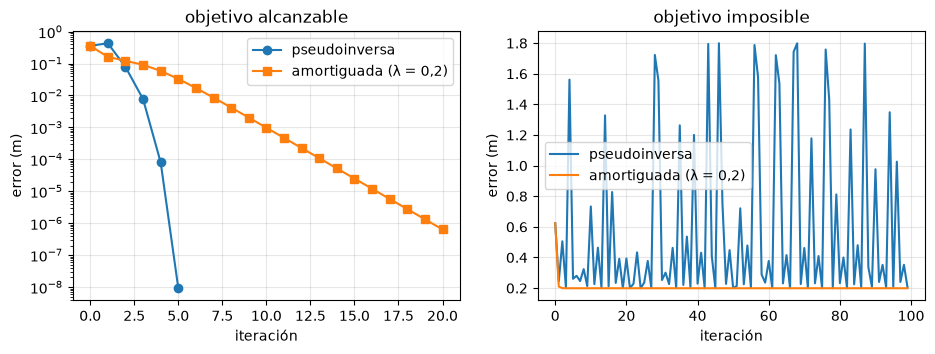

In [29]:
_, errores_cerca_pinv = ik_pseudoinversa(objetivo, q_inicial)
_, errores_cerca_dls = ik_amortiguada(objetivo, q_inicial, amortiguacion=0.2)

fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 3.5))
izq.semilogy(errores_cerca_pinv, "o-", label="pseudoinversa")
izq.semilogy(errores_cerca_dls, "s-", label="amortiguada (λ = 0,2)")
izq.set_title("objetivo alcanzable")
der.plot(errores_pinv, label="pseudoinversa")
der.plot(errores_dls, label="amortiguada (λ = 0,2)")
der.set_title("objetivo imposible")
for eje in (izq, der):
    eje.set_xlabel("iteración")
    eje.set_ylabel("error (m)")
    eje.legend()
    eje.grid(alpha=0.3)
plt.show()

Las dos gráficas resumen la elección:

- **Izquierda, objetivo alcanzable** (eje vertical logarítmico, `semilogy`, para ver errores de 10⁻¹ a 10⁻⁷ en la misma gráfica): la pseudoinversa llega en 6 iteraciones; la amortiguada con λ = 0,2, en unas 20. **La amortiguación cuesta velocidad**: cada paso es más corto de lo que podría ser.
- **Derecha, objetivo imposible**: la pseudoinversa salta sin parar (y sus ángulos explotan); la amortiguada baja a 0,199 y se queda.

Por eso, en la práctica, se usa la amortiguada con un λ **pequeño** (que casi no frena lejos de las singularidades) o un λ **variable**, que crece solo cuando el jacobiano se acerca a la singularidad (ejercicio E5). Es el compromiso de siempre: **velocidad frente a robustez**.


### El pie dibuja un círculo

Para terminar la cinemática inversa, algo visual: pedimos al tobillo que recorra un **círculo** de 10 cm de radio, delante y debajo de la cadera, y resolvemos la cinemática inversa en cada punto, **empezando desde la solución del punto anterior** (así cada resolución tarda muy pocas iteraciones: el objetivo apenas se ha movido). Es exactamente lo que hará un controlador que mueve el pie siguiendo una trayectoria (NB51, NB52). Solo usamos cinemática (`mj_forward`): el robot no "simula" nada, solo lo colocamos.


iteraciones por punto: de 3 a 7
error máximo: 9.6e-07 m


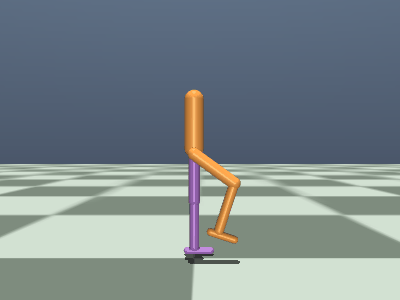

In [30]:
import imageio
from IPython.display import Image

centro = np.array([0.1, -0.1, 0.25])
q = q_inicial.copy()
camara = mujoco.Renderer(modelo, height=300, width=400)
fotos, iteraciones_por_punto, errores_finales = [], [], []
for angulo in np.linspace(0, 2 * np.pi, 60):
    objetivo = centro + 0.1 * np.array([np.cos(angulo), 0.0, np.sin(angulo)])
    angulos, errores = ik_amortiguada(objetivo, q, amortiguacion=0.05)
    q[COLUMNAS] = angulos                     # la próxima vez, partimos de aquí
    iteraciones_por_punto.append(len(errores))
    errores_finales.append(errores[-1])
    mujoco.mj_forward(modelo, datos)
    camara.update_scene(datos, camera="lado")
    fotos.append(camara.render())
camara.close()

os.makedirs("assets", exist_ok=True)
imageio.mimsave("assets/nb46_circulo.gif", fotos, fps=20, loop=0)
print("iteraciones por punto: de", min(iteraciones_por_punto), "a", max(iteraciones_por_punto))
print(f"error máximo: {max(errores_finales):.1e} m")
Image(filename="assets/nb46_circulo.gif")

El tobillo derecho recorre el círculo con un error máximo de **una millonésima de metro**, y cada punto se resuelve en **3 a 7 iteraciones**, gracias a empezar desde la solución anterior (arrancar "en caliente", como el warmstart del NB45).

Fíjate en el **pie**: cambia de inclinación a lo largo del círculo. Le pedimos a la IK solo la **posición** del tobillo, y el tobillo se quedó en su ángulo de partida, así que el pie se inclina con la pierna. Para que el pie se mantenga **plano** (lo necesario para apoyarlo en el suelo), habría que pedirle también una **orientación**, con el jacobiano de rotación: es el ejercicio del NB47.

Dos detalles de código: `mujoco.Renderer(modelo, height=..., width=...)` crea la cámara (NB34) y hay que **cerrarla** al final (`camara.close()`) para liberar la memoria gráfica; y `camera="lado"` usa la cámara que le pusimos a Zancudo en el NB42.


## 10 · Python profesional: funciones puras, docstrings y tests

### El problema de nuestras funciones de IK

`ik_pseudoinversa` e `ik_amortiguada` funcionan, pero tienen un defecto de diseño serio: **modifican `datos`**, una variable **global** (definida fuera de la función). Después de llamarlas, el robot ha cambiado de postura, aunque la función solo debía "calcular unos ángulos". Eso se llama un **efecto secundario** (*side effect*), y causa errores muy difíciles de encontrar: una función que llamaste para "preguntar algo" te ha cambiado el mundo por debajo.

Una **función pura** es una que:

1. solo depende de sus **argumentos** (no lee variables globales que puedan cambiar), y
2. no tiene **efectos secundarios** (no modifica nada de fuera: ni globales, ni sus argumentos, ni ficheros...).

Por tanto, con los mismos argumentos, **siempre** devuelve lo mismo, como una función matemática. ¿Por qué importa tanto?

- **Se pueden probar** (tests) fácilmente: llamas, compruebas el resultado, y ya.
- **Se pueden ejecutar en paralelo** sin miedo: nadie pisa los datos de nadie (NB49).
- **Se entienden** leyendo solo la función.
- Y en el NB59 veremos que **JAX** (la base de MJX, MuJoCo en GPU) **exige** funciones puras para poder acelerarlas.

`jacobiano_numerico` (sección 6) ya era pura: creaba sus propios `MjData`. Ese es el truco para hacer puras las funciones que usan MuJoCo: **datos propios**. Tiene un coste (crear un `MjData` tarda un poco), así que en código muy exigente se hace un término medio: pasar los datos "de trabajo" como argumento, y dejar claro en la documentación que se modifican.

### Docstrings estilo NumPy

En el NB45 escribimos una docstring sencilla. En proyectos científicos de Python, el estándar es el **estilo NumPy**: secciones con títulos subrayados (`Parameters`, `Returns`, `Raises`, `Examples`...), que herramientas como Sphinx convierten en páginas web de documentación automáticamente (así está hecha la documentación de NumPy, SciPy, scikit-learn...). Lo verás en el módulo de la sección siguiente.

### Tipos para arrays: numpy.typing

Para anotar arrays con más precisión que `np.ndarray`, NumPy trae el módulo `numpy.typing`, con `NDArray[np.float64]`: "un array de NumPy de decimales de 64 bits". Y como escribir eso muchas veces es pesado, se crea un **alias de tipo**: un nombre corto para un tipo largo, `Vector = NDArray[np.float64]`. En Python 3.12 en adelante hay una sintaxis especial para eso: `type Vector = NDArray[np.float64]`.


### Un módulo de verdad

Vamos a juntar lo mejor del notebook en un **módulo** (NB26), `cinematica.py`, escrito como en un proyecto profesional: funciones puras, anotaciones, docstrings estilo NumPy. Para escribirlo desde el notebook usaremos una **magia** de Jupyter: una celda que empieza por `%%writefile ruta` no se ejecuta como Python, sino que **guarda su contenido en un fichero**. (Las "magias" son órdenes especiales de Jupyter que empiezan por `%`; no son Python, y no funcionan en un script normal.)

Primero, la carpeta de prácticas (como en la Parte 3; no se sube a GitHub):


In [31]:
PRACTICA = Path("practica_nb46")
PRACTICA.mkdir(exist_ok=True)
print(PRACTICA.resolve())

/home/gregori/dev/robotica/notebooks/practica_nb46


In [32]:
%%writefile practica_nb46/cinematica.py
"""Cinemática de robots con MuJoCo: jacobianos y cinemática inversa.

Funciones puras: ninguna modifica los MjData que recibe (todas usan datos propios).
"""
from __future__ import annotations

import mujoco
import numpy as np
from numpy.typing import NDArray

Vector = NDArray[np.float64]
Matriz = NDArray[np.float64]


def posicion_site(modelo: mujoco.MjModel, qpos: Vector, site: int) -> Vector:
    """Posición de un site en el mundo para una postura dada.

    Parameters
    ----------
    modelo : mujoco.MjModel
        El modelo del robot.
    qpos : Vector
        La postura (coordenadas generalizadas), de longitud ``modelo.nq``.
    site : int
        El número del site.

    Returns
    -------
    Vector
        La posición (x, y, z) del site, en metros.
    """
    datos = mujoco.MjData(modelo)
    datos.qpos[:] = qpos
    mujoco.mj_kinematics(modelo, datos)
    return datos.site_xpos[site].copy()


def jacobiano(modelo: mujoco.MjModel, qpos: Vector, site: int) -> Matriz:
    """Jacobiano de posición (3 × nv) de un site, calculado por MuJoCo.

    Examples
    --------
    >>> J = jacobiano(modelo, np.zeros(modelo.nq), modelo.site("tobillo_d").id)
    >>> J.shape
    (3, 9)
    """
    datos = mujoco.MjData(modelo)
    datos.qpos[:] = qpos
    mujoco.mj_forward(modelo, datos)              # ¡no basta mj_kinematics! (hace falta mj_comPos)
    J = np.zeros((3, modelo.nv))
    mujoco.mj_jacSite(modelo, datos, J, None, site)
    return J


def cinematica_inversa(
    modelo: mujoco.MjModel,
    objetivo: Vector,
    q_inicial: Vector,
    site: int,
    columnas: list[int],
    filas: list[int] | None = None,
    amortiguacion: float = 0.1,
    iteraciones: int = 100,
    tolerancia: float = 1e-6,
) -> tuple[Vector, float]:
    """Cinemática inversa por mínimos cuadrados amortiguados (Levenberg-Marquardt).

    Parameters
    ----------
    modelo : mujoco.MjModel
        El modelo del robot.
    objetivo : Vector
        Posición (x, y, z) deseada del site.
    q_inicial : Vector
        Postura de partida (longitud ``modelo.nq``). No se modifica.
    site : int
        El número del site que queremos colocar.
    columnas : list[int]
        Qué grados de libertad puede mover la cinemática inversa.
    filas : list[int] or None
        Qué coordenadas del objetivo importan (por defecto, las tres).
    amortiguacion : float
        El λ del método. Más grande: más estable, pero más lento.
    iteraciones, tolerancia
        Cuándo parar.

    Returns
    -------
    qpos : Vector
        La postura encontrada (una copia nueva).
    error : float
        La distancia que queda hasta el objetivo, en metros.

    Raises
    ------
    ValueError
        Si ``q_inicial`` no tiene longitud ``modelo.nq``.
    """
    if len(q_inicial) != modelo.nq:
        raise ValueError(f"q_inicial debe tener {modelo.nq} números, no {len(q_inicial)}")
    filas = [0, 1, 2] if filas is None else filas
    datos = mujoco.MjData(modelo)
    datos.qpos[:] = q_inicial
    J = np.zeros((3, modelo.nv))
    error = np.inf
    for _ in range(iteraciones):
        mujoco.mj_forward(modelo, datos)
        diferencia = (np.asarray(objetivo) - datos.site_xpos[site])[filas]
        error = float(np.linalg.norm(diferencia))
        if error < tolerancia:
            break
        mujoco.mj_jacSite(modelo, datos, J, None, site)
        Jr = J[filas][:, columnas]
        A = Jr @ Jr.T + amortiguacion**2 * np.eye(len(filas))
        datos.qpos[columnas] += Jr.T @ np.linalg.solve(A, diferencia)
    return datos.qpos.copy(), error

Overwriting practica_nb46/cinematica.py


Repasemos lo que hay de nuevo:

- **La docstring del módulo**, arriba del todo: qué contiene el fichero. Y una promesa importante: "funciones puras".
- **`from __future__ import annotations`** (NB45): hace que todas las anotaciones se traten como texto, así que se pueden usar nombres que aún no existen y no cuestan nada al ejecutar. Es habitual ponerlo en todos los módulos.
- **Los alias** `Vector` y `Matriz`: las firmas de las funciones se leen mucho mejor.
- **`list[int] | None = None`** con un `if ... is None` dentro: es el patrón correcto para un argumento **opcional mutable**. Nunca se pone `filas: list[int] = [0, 1, 2]` como valor por defecto: esa lista se crearía **una sola vez** y se compartiría entre todas las llamadas (la famosa trampa de los argumentos por defecto mutables, NB23).
- **`raise ValueError(...)`** al principio: comprobar los argumentos y fallar **pronto y con un mensaje claro** (NB22), en vez de dejar que el error salga diez líneas más abajo con un mensaje incomprensible de NumPy. La docstring lo documenta en `Raises`.
- **Devuelve una tupla** `(qpos, error)`: quien llama decide qué hacer si no se alcanzó el objetivo (¿era imposible?), en vez de que la función lo esconda.
- **La sección `Examples`** de `jacobiano` usa el formato `>>>` de la consola de Python. Es documentación, y además se puede **ejecutar** como test con el módulo `doctest` de la biblioteca estándar.

Lo importamos como cualquier módulo. Como la carpeta `practica_nb46` no está en la lista de sitios donde Python busca módulos, la añadimos a `sys.path` (NB26):


In [33]:
import sys
sys.path.insert(0, str(PRACTICA))
import cinematica

q, error = cinematica.cinematica_inversa(modelo, np.array([0.2, -0.1, 0.25]), q_inicial, TOBILLO,
                                          columnas=[3, 4], filas=[0, 2])
print("ángulos:", q[[3, 4]], "  error:", error)
print("¿ha cambiado q_inicial?", q_inicial[[3, 4]])

ángulos: [ 0.9438 -1.2588]   error: 4.6087449924659626e-07
¿ha cambiado q_inicial? [ 0.  -0.3]


Los mismos ángulos que antes, y **`q_inicial` no ha cambiado**: la función es pura. Ahora, a probarla.

### Tests para código numérico

En el NB27 escribimos nuestros primeros tests con pytest. El código numérico tiene sus propias técnicas de test, y vamos a usar las tres más importantes:

1. **Comparar con tolerancia**: `np.testing.assert_allclose(a, b, atol=...)`. Como `pytest.approx`, pero para arrays, y cuando falla te dice **qué casillas** difieren y cuánto.
2. **Comparar con otro método independiente**: el jacobiano de MuJoCo contra diferencias finitas. Si dos formas distintas de calcular lo mismo coinciden, es muy improbable que las dos estén mal de la misma manera.
3. **Probar con muchos casos al azar** (*property-based testing*, en su versión sencilla): en vez de una postura escogida a mano, 20 posturas aleatorias... pero con una **semilla fija** (NB28), para que el test sea **reproducible**: si falla, falla siempre igual.

Y una herramienta nueva de pytest: **`@pytest.mark.parametrize`**, que ejecuta el mismo test con varios valores, como si fueran varios tests.


In [34]:
%%writefile practica_nb46/test_cinematica.py
from pathlib import Path

import mujoco
import numpy as np
import pytest

import cinematica

XML = Path(__file__).parent.parent / "robots" / "zancudo.xml"


@pytest.fixture(scope="module")
def modelo():
    texto = XML.read_text(encoding="utf-8")
    buscado = '<body name="pie_d" pos="0 0 -0.4">'
    texto = texto.replace(buscado, buscado + '<site name="tobillo_d" pos="0 0 0"/>')
    return mujoco.MjModel.from_xml_string(texto)


def test_jacobiano_igual_que_diferencias_finitas(modelo):
    site = modelo.site("tobillo_d").id
    rng = np.random.default_rng(seed=0)
    for _ in range(20):
        q = rng.uniform(-1, 1, size=modelo.nq)
        J = cinematica.jacobiano(modelo, q, site)
        eps = 1e-6
        for k in range(modelo.nv):
            mas, menos = q.copy(), q.copy()
            mas[k] += eps
            menos[k] -= eps
            columna = (cinematica.posicion_site(modelo, mas, site)
                       - cinematica.posicion_site(modelo, menos, site)) / (2 * eps)
            np.testing.assert_allclose(J[:, k], columna, atol=1e-7)


@pytest.mark.parametrize("objetivo", [
    [0.2, -0.1, 0.25],
    [-0.2, -0.1, 0.3],
    [0.0, -0.1, 0.5],
])
def test_alcanza_objetivos_alcanzables(modelo, objetivo):
    site = modelo.site("tobillo_d").id
    q0 = np.zeros(modelo.nq)
    q0[4] = -0.3
    q, error = cinematica.cinematica_inversa(modelo, np.array(objetivo), q0, site,
                                             columnas=[3, 4], filas=[0, 2])
    assert error < 1e-5
    np.testing.assert_allclose(cinematica.posicion_site(modelo, q, site)[[0, 2]],
                               np.array(objetivo)[[0, 2]], atol=1e-5)


def test_objetivo_imposible_se_queda_lo_mas_cerca_posible(modelo):
    site = modelo.site("tobillo_d").id
    q0 = np.zeros(modelo.nq)
    q0[4] = -0.3
    lejos = np.array([0.5, -0.1, 0.0])
    cadera = np.array([0.0, -0.1, 0.865])
    q, error = cinematica.cinematica_inversa(modelo, lejos, q0, site, columnas=[3, 4],
                                             filas=[0, 2], amortiguacion=0.2)
    assert error == pytest.approx(np.linalg.norm(lejos - cadera) - 0.8, abs=1e-3)
    assert np.all(np.abs(q) < 10)           # nada de ángulos disparatados


def test_no_modifica_la_postura_inicial(modelo):
    q0 = np.zeros(modelo.nq)
    copia = q0.copy()
    cinematica.cinematica_inversa(modelo, np.array([0.2, -0.1, 0.25]), q0,
                                  modelo.site("tobillo_d").id, columnas=[3, 4], filas=[0, 2])
    np.testing.assert_array_equal(q0, copia)


def test_rechaza_una_postura_de_tamano_equivocado(modelo):
    with pytest.raises(ValueError, match="debe tener 9"):
        cinematica.cinematica_inversa(modelo, np.zeros(3), np.zeros(5), 0, columnas=[3, 4])

Overwriting practica_nb46/test_cinematica.py


Lo nuevo en los tests:

- **`@pytest.fixture`**: una función que **prepara** algo que necesitan los tests (aquí, el modelo con el site). Los tests la piden poniendo su **nombre como argumento** (`def test_...(modelo):`), y pytest se la pasa automáticamente. Con `scope="module"`, el modelo se carga **una sola vez** para todos los tests del fichero, en vez de una por test. Es la forma estándar de compartir preparativos.
- **`Path(__file__).parent.parent`**: `__file__` es la ruta del propio fichero de test; dos `.parent` suben dos carpetas (de `practica_nb46/test_cinematica.py` a `notebooks/`). Así el test encuentra el MJCF **se ejecute desde donde se ejecute**: nunca uses rutas relativas "a ciegas" en los tests.
- **`np.random.default_rng(seed=0)`**: el generador de números aleatorios moderno de NumPy (NB28), con semilla: las 20 posturas "al azar" son siempre las mismas.
- **`@pytest.mark.parametrize("objetivo", [...])`**: el test se ejecuta tres veces, una por objetivo. Si falla uno, pytest dice **cuál**.
- **`pytest.raises(ValueError, match="debe tener 9")`**: comprueba que el código **falla como debe**, con el tipo de error y el mensaje correctos. Probar los errores es tan importante como probar los aciertos.
- **Un test por idea**, con un nombre que es una frase: `test_no_modifica_la_postura_inicial`. Cuando uno falle, el nombre te dice qué se ha roto sin abrir el fichero.

Ejecutémoslos, como en el NB27:


In [35]:
import subprocess

resultado = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "--color=no"],
                           cwd=PRACTICA, capture_output=True, text=True)
print(resultado.stdout[-600:])

.......                                                                  [100%]
7 passed in 0.52s



**7 passed**: el test del jacobiano (que compara las 9 columnas en 20 posturas al azar), los tres objetivos alcanzables del `parametrize`, el objetivo imposible, el de la pureza y el del error. Cada `.` es un test.

Fíjate en lo que nos dan estos tests: si mañana cambias `cinematica.py` (para hacerlo más rápido, por ejemplo), ejecutas `pytest` y en medio segundo sabes si has roto algo. Y el test del objetivo imposible comprueba una **propiedad** física ("el error que queda es la distancia menos lo que mide la pierna"), no un número copiado de una ejecución anterior: es mucho más robusto.


## 11 · Resumen de la lección

1. **Marcos de referencia**: el mundo y uno por cuerpo. MuJoCo guarda la pose relativa a la madre en el modelo (`body_pos`, `body_quat`) y la del mundo en los datos (`xpos`, `xquat`, `xmat`). Cinemática directa = encadenar marcos. Cambio de marco: mundo = p + R·a; a = Rᵀ·(mundo − p).
2. **Matriz de rotación**: columnas = ejes del cuerpo en el mundo; RᵀR = I, det = +1, inversa = traspuesta; componer = multiplicar, y **el orden importa** en 3D. `xmat` viene aplanada (`reshape(3, 3)`).
3. **Ángulos de Euler**: intuitivos para mostrar, pero con 12 × 2 convenios y **bloqueo de cardán** (con cabeceo de 90°, guiñada y alabeo se funden).
4. **Cuaterniones**: (cos θ/2, sen θ/2 · eje), unitarios. MuJoCo: **(w, x, y, z)**; SciPy/ROS/Unity: (x, y, z, w). **q y −q** son el mismo giro. Componer con `mju_mulQuat`, interpolar con **slerp**.
5. **Cinemática directa** de la pierna de Zancudo a mano = MuJoCo. Marca los puntos de interés con **sites**.
6. **Jacobiano** J (3 × nv): pendientes de la posición respecto a cada articulación. `mj_jacSite` (¡después de `mj_forward`, o devuelve ceros!). **v = J·q̇**; **τ = Jᵀ·f** (trabajo virtual): con la rodilla casi estirada, sostener el peso cuesta muy poco par.
7. **Singularidades**: el jacobiano pierde rango (columnas paralelas, determinante 0, número de condición infinito). La pierna estirada lo es.
8. **np.linalg**: `solve` mejor que `inv`; `lstsq`/`pinv` para matrices no cuadradas; `cond` y `svd` para diagnosticar.
9. **Cinemática inversa**: Newton con la pseudoinversa (rápida, pero explota cerca de singularidades y con objetivos imposibles) o **mínimos cuadrados amortiguados**, Δq = Jᵀ(JJᵀ + λ²I)⁻¹e: el método estándar. Arrancar desde la solución anterior al seguir trayectorias.
10. Python profesional: **funciones puras** (datos propios), docstrings **estilo NumPy**, `numpy.typing.NDArray` y **alias de tipo**, `%%writefile`, programación defensiva (`assert`, `raise ValueError`), argumentos opcionales con `None`, y **tests numéricos** (assert_allclose, comparar con otro método, azar con semilla, fixtures, parametrize, `pytest.raises`).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Marco de referencia** | Un origen y unos ejes desde los que se describen posiciones. |
| **Cinemática directa / inversa** | Ángulos → posición / posición deseada → ángulos. |
| **Matriz ortogonal** | Cuyas columnas son perpendiculares y de longitud 1 (RᵀR = I). |
| **Ángulos de Euler** | Tres giros seguidos alrededor de ejes; muchos convenios. |
| **Extrínseco / intrínseco** | Giros alrededor de ejes fijos / de ejes que giran con el cuerpo. |
| **Eje-ángulo** | Todo giro 3D es girar θ alrededor de un eje. |
| **Doble cobertura** | Cada giro tiene dos cuaterniones: q y −q. |
| **Slerp** | Interpolación esférica entre cuaterniones: camino corto, velocidad constante. |
| **Jacobiano** | Matriz de las pendientes de varias salidas respecto a varias entradas. |
| **Diferencias finitas** | Calcular pendientes moviendo un poquito la entrada. |
| **Trabajo virtual** | Principio que da τ = Jᵀ·f. |
| **Singularidad** | Postura en que el jacobiano pierde una dirección (pierna estirada). |
| **Número de condición** | Mayor/menor valor singular: cuánto amplifica errores una matriz. |
| **Pseudoinversa** | La "mejor inversa" de una matriz no cuadrada o singular. |
| **Mínimos cuadrados amortiguados** | IK estable: Δq = Jᵀ(JJᵀ + λ²I)⁻¹e. |
| **Función pura** | Solo depende de sus argumentos y no modifica nada de fuera. |
| **Alias de tipo** | Nombre corto para un tipo largo: `Vector = NDArray[np.float64]`. |
| **Fixture** | Preparativo compartido por los tests de pytest. |


## 12 · Ejercicios

**E1.** Con `giro_x`, `giro_y` y `giro_z`, calcula el giro que resulta de girar 90° alrededor de x, luego 90° alrededor de y y luego −90° alrededor de x (todos con los ejes del mundo). ¿Es un giro sencillo alrededor de algún eje? ¿Cuál? (Pista: mira las columnas de la matriz resultante.)

**E2.** Escribe una función `cuaterniones_iguales(q1, q2, tol=1e-9)` que diga si dos cuaterniones representan **el mismo giro** (teniendo en cuenta la doble cobertura). Pruébala con q y −q.

**E3.** Calcula el jacobiano del **centro de masas de todo Zancudo** con `mj_jacSubtreeCom` (el cuerpo 1, el torso, "contiene" todo el robot). ¿Qué columna tiene el número más grande en la fila x? ¿Y sin contar las de la raíz? ¿Por qué? (Este jacobiano es la base del control de equilibrio del NB47.)

**E4.** Cinemática inversa **analítica** de la pierna de Zancudo: con el teorema del coseno (NB36), deduce la rodilla a partir de la distancia d de la cadera al tobillo (cos(π + r) = (0,4² + 0,4² − d²) / (2 · 0,4 · 0,4)), y luego la cadera. Comprueba que coincide con la iterativa para el objetivo (0,2, −0,1, 0,25).

**E5.** En `ik_amortiguada` con el objetivo alcanzable, prueba λ = 0,01, 0,1, 0,5 y 1. ¿Cuántas iteraciones hace falta en cada caso? ¿Por qué no usar siempre un λ grande?

**E6.** **Reto.** Añade al módulo `cinematica.py` una función `jacobiano_numerico` pura (como la de la sección 6) y un test que compruebe, para 10 posturas al azar con semilla, que coincide con `jacobiano`. Después, **rompe** a propósito `jacobiano` (cambia `mj_forward` por `mj_kinematics`) y comprueba que el test lo detecta. Déjalo arreglado.


<details>
<summary>▶ Solución E1</summary>

```python
R = giro_x(-np.pi / 2) @ giro_y(np.pi / 2) @ giro_x(np.pi / 2)    # primero x, luego y, luego −x
print(R.round(4))
print(np.allclose(R, giro_z(-np.pi / 2)))      # True
```

Es un giro de **−90° alrededor de z** (o, lo que es lo mismo, de 90° alrededor de −z). Mirando las columnas: el eje x del cuerpo acaba en (0, −1, 0), el y en (1, 0, 0), y el z no se mueve. Este truco (girar, hacer algo y "desgirar") se llama **conjugación**: "girar alrededor de y, visto desde unos ejes girados 90° alrededor de x", es girar alrededor del eje en que se ha convertido y, que es −z.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
def cuaterniones_iguales(q1: np.ndarray, q2: np.ndarray, tol: float = 1e-9) -> bool:
    return bool(np.allclose(q1, q2, atol=tol) or np.allclose(q1, -q2, atol=tol))

q = cuaternion([0, 0, 1], 0.7)
print(cuaterniones_iguales(q, -q), cuaterniones_iguales(q, cuaternion([0, 0, 1], 0.8)))    # True False
```

Otra forma, muy usada: |q1 · q2| (el producto escalar en valor absoluto) vale 1 si son el mismo giro, sea cual sea el signo. Y de ahí sale la **distancia** entre dos orientaciones: el ángulo 2 · arccos(|q1 · q2|).
</details>

<details>
<summary>▶ Solución E3</summary>

```python
datos.qpos[:] = 0
mujoco.mj_forward(modelo, datos)
J_cdm = np.zeros((3, modelo.nv))
mujoco.mj_jacSubtreeCom(modelo, datos, J_cdm, 1)       # 1 = el torso, que contiene todo el robot
print(J_cdm)
```

En la fila x, el mayor es la **columna 0** (la raíz x), que vale **1**: si todo el robot avanza 1 m, su centro de masas también. Sin contar la raíz, los mayores son las dos **caderas** (0,104 cada una): mover una cadera balancea una pierna entera (5,8 kg de 23,6), y el CdM se desplaza 0,104 m por radián. Las rodillas mueven menos (0,031) y los tobillos casi nada (0,001). El giro del torso (−0,082) mueve el CdM hacia atrás, porque los 12 kg del torso están **por encima** de su eje.

Este jacobiano dice **cómo mover las articulaciones para mover el centro de masas**: justo lo que hace falta para el equilibrio (mantener el CdM sobre los pies, NB38). Lo usaremos en el NB47 y en el NB52.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
objetivo = np.array([0.2, -0.1, 0.25])
dx, dz = objetivo[0], objetivo[2] - 0.865            # del centro de la cadera al objetivo
d = np.hypot(dx, dz)                                 # distancia (np.hypot = √(dx² + dz²))
rodilla = -(np.pi - np.arccos((0.4**2 + 0.4**2 - d**2) / (2 * 0.4 * 0.4)))
direccion = np.arctan2(dx, -dz)                      # ángulo de la recta cadera→tobillo con la vertical
apertura = np.arccos(d / (2 * 0.4))                  # ángulo entre esa recta y el muslo (triángulo isósceles)
cadera = direccion + apertura
print(cadera, rodilla)                               # 0.9438  −1.2588
```

El triángulo cadera-rodilla-tobillo tiene dos lados de 0,4 y uno de d. El ángulo **interior** en la rodilla, por el teorema del coseno, es arccos((0,4² + 0,4² − d²) / (2·0,4·0,4)), y el ángulo de la rodilla de Zancudo es lo que le falta para 180°, con signo negativo. La cadera es la dirección del objetivo **más** la apertura del muslo respecto a esa dirección. Coincide con la IK iterativa: **0,9438 y −1,2588**.

¿Por qué no usar siempre la fórmula? Para dos eslabones en un plano es lo mejor (exacta e instantánea). Pero hay **dos** soluciones (rodilla hacia delante o hacia atrás: aquí elegimos la de Zancudo con el signo), y para robots con más articulaciones las fórmulas se vuelven monstruosas o no existen. La iterativa sirve para todo.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for lam in [0.01, 0.1, 0.5, 1.0]:
    _, errores = ik_amortiguada(np.array([0.2, -0.1, 0.25]), q_inicial, amortiguacion=lam)
    print(lam, len(errores), errores[-1])
```

λ = 0,01 → **7** iteraciones; λ = 0,1 → **9**; λ = 0,5 → **98**; λ = 1 → **no llega** en las 100 iteraciones (necesitaría unas 370). Un λ grande hace cada paso **más corto** (el término λ² pesa más que JJᵀ), así que se avanza muy despacio. En el límite, con λ enorme, el método se convierte en un descenso por gradiente con un paso diminuto (Δq ≈ Jᵀe / λ², NB17). El arte está en un λ lo bastante grande para no explotar cerca de las singularidades y lo bastante pequeño para no frenar lejos de ellas: por eso los métodos profesionales lo **adaptan** en cada iteración (si el error baja, se reduce λ; si sube, se aumenta).
</details>

<details>
<summary>▶ Solución E6</summary>

Añade al módulo (por ejemplo, volviendo a ejecutar el `%%writefile` con la función nueva al final):

```python
def jacobiano_numerico(modelo: mujoco.MjModel, qpos: Vector, site: int, eps: float = 1e-6) -> Matriz:
    """Jacobiano de posición por diferencias finitas centradas (solo para nq == nv)."""
    J = np.zeros((3, modelo.nv))
    for k in range(modelo.nv):
        mas, menos = qpos.copy(), qpos.copy()
        mas[k] += eps
        menos[k] -= eps
        J[:, k] = (posicion_site(modelo, mas, site) - posicion_site(modelo, menos, site)) / (2 * eps)
    return J
```

y al fichero de tests:

```python
def test_jacobiano_numerico_coincide(modelo):
    site = modelo.site("tobillo_d").id
    rng = np.random.default_rng(seed=1)
    for _ in range(10):
        q = rng.uniform(-1, 1, size=modelo.nq)
        np.testing.assert_allclose(cinematica.jacobiano(modelo, q, site),
                                   cinematica.jacobiano_numerico(modelo, q, site), atol=1e-7)
```

Si cambias `mj_forward` por `mj_kinematics` en `jacobiano`, el jacobiano sale a ceros (sección 6) y **dos** tests fallan (este y el del principio), con un mensaje de `assert_allclose` que dice cuántas casillas difieren y la diferencia máxima. Ese es el valor de los tests: el error de una línea que en la sección 6 nos costó un rato ver, aquí salta solo.
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB47** usaremos todo esto para **controlar** con el modelo: la **dinámica inversa** (`mj_inverse`: ¿qué pares necesito para esta aceleración?), la **compensación de la gravedad**, el **par calculado** y el **control en el espacio de la tarea** (mover el pie directamente, con el jacobiano). Y en Python: clases abstractas y protocolos para diseñar una familia de **controladores** intercambiables.
